Importamos 

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel


sns.set_theme(style="whitegrid")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

SCORING_MAIN = "f1"

In [378]:
df_raw= pd.read_csv("/Users/juanfelipe/Documents/Datos_Taller1/Punto1/train.csv")

In [379]:
df_raw.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,NaN,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
3,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4
4,ID_ec05b1a7b,180000.0,0,5,0,1,1,1,1.0,0,...,121,1444,16,121,4,1.777778,1.0,121.0,1444,4


Asignamos el target ara que sea binario

Re definimos variables para que sean numericas

In [ ]:
df_ed = df_raw.replace("no", 99)
df_ed = df_ed.replace("yes", 1)
df_ed.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,age,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq
0,ID_1c08ffb74,NaN,0,4,0,1,1,0,NaN,0,...,36,36,1296,1,0,0,0.250000,0.0000,36.00,1296
1,ID_503cfc817,70000.0,0,4,0,1,1,0,NaN,0,...,45,36,2025,9,25,1,2.250000,0.2500,30.25,2025
2,ID_59e21a8c4,NaN,0,3,0,1,1,1,1.0,1,...,36,121,1296,9,81,1,9.000000,0.2500,100.00,1296
3,ID_a5bedc6c4,NaN,0,4,0,1,1,1,1.0,1,...,68,0,4624,16,0,1,4.000000,9.0000,36.00,4624
4,ID_95533259b,90000.0,0,6,0,1,1,1,2.0,0,...,97,0,9409,25,121,0,2.777778,0.0625,64.00,9409


In [ ]:
string_cols = df_ed.select_dtypes(include=['object']).columns.tolist()
print(string_cols)
print(X_raw[string_cols].dtypes)



['Id', 'idhogar', 'dependency', 'edjefe', 'edjefa']
Id            str
idhogar       str
dependency    str
edjefe        str
edjefa        str
dtype: object


/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/3607015577.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = X_ed.select_dtypes(include=['object']).columns.tolist()


In [ ]:
df_ed['dependency']=df_ed['dependency'].astype(float)
df_ed['edjefe']=df_ed['edjefe'].astype(float)
df_ed['edjefa']=df_ed['edjefa'].astype(float)


Verificamos missing values para ver como accionar

In [ ]:
missing_pct = df_ed.isna().mean().sort_values(ascending=False) * 100

missing_pct = missing_pct[missing_pct > 0]
missing_pct



rez_esc      82.838008
v18q1        76.949909
v2a1         72.080368
meaneduc      0.027906
SQBmeaned     0.027906
dtype: float64

cambiamos que si v18q1 es NaN es = 0 tablets

In [ ]:
df_ed['v18q1'] = df_ed['v18q1'].fillna(0)
df_ed.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,age,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq
0,ID_1c08ffb74,NaN,0,4,0,1,1,0,0.0,0,...,36,36,1296,1,0,0,0.250000,0.0000,36.00,1296
1,ID_503cfc817,70000.0,0,4,0,1,1,0,0.0,0,...,45,36,2025,9,25,1,2.250000,0.2500,30.25,2025
2,ID_59e21a8c4,NaN,0,3,0,1,1,1,1.0,1,...,36,121,1296,9,81,1,9.000000,0.2500,100.00,1296
3,ID_a5bedc6c4,NaN,0,4,0,1,1,1,1.0,1,...,68,0,4624,16,0,1,4.000000,9.0000,36.00,4624
4,ID_95533259b,90000.0,0,6,0,1,1,1,2.0,0,...,97,0,9409,25,121,0,2.777778,0.0625,64.00,9409


In [ ]:
df_ed['v2a1_reg'] = df_ed['v2a1'].notna().astype(int)
df_ed[['v2a1', 'v2a1_reg']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/4280733851.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_ed['v2a1_reg'] = X_ed['v2a1'].notna().astype(int)


,v2a1,v2a1_reg
0,NaN,0
1,70000.0,1
2,NaN,0
3,NaN,0
4,90000.0,1


In [ ]:
df_ed=df_ed.drop('v2a1', axis=1)
df_ed.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg
0,ID_1c08ffb74,0,4,0,1,1,0,0.0,0,0,...,36,1296,1,0,0,0.250000,0.0000,36.00,1296,0
1,ID_503cfc817,0,4,0,1,1,0,0.0,0,2,...,36,2025,9,25,1,2.250000,0.2500,30.25,2025,1
2,ID_59e21a8c4,0,3,0,1,1,1,1.0,1,1,...,121,1296,9,81,1,9.000000,0.2500,100.00,1296,0
3,ID_a5bedc6c4,0,4,0,1,1,1,1.0,1,1,...,0,4624,16,0,1,4.000000,9.0000,36.00,4624,0
4,ID_95533259b,0,6,0,1,1,1,2.0,0,3,...,0,9409,25,121,0,2.777778,0.0625,64.00,9409,1


In [ ]:
df_ed['rezago'] = df_ed['rez_esc'].notna().astype(int)
df_ed[['rez_esc', 'rezago']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/3283194451.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_ed['rezago'] = X_ed['rez_esc'].notna().astype(int)


,rez_esc,rezago
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [ ]:
# crear columna 'gran rezago' en X_ed: 1 si rez_esc >= 3, else 0
df_ed['gran_rezago'] = (df_ed['rez_esc'] >= 3).astype(int)
df_ed[['rez_esc', 'gran_rezago']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/698006792.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_ed['gran_rezago'] = (X_ed['rez_esc'] >= 3).astype(int)


,rez_esc,gran_rezago
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [ ]:
df_ed=df_ed.drop('rez_esc', axis=1)
df_ed.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago
0,ID_1c08ffb74,0,4,0,1,1,0,0.0,0,0,...,1,0,0,0.250000,0.0000,36.00,1296,0,0,0
1,ID_503cfc817,0,4,0,1,1,0,0.0,0,2,...,9,25,1,2.250000,0.2500,30.25,2025,1,0,0
2,ID_59e21a8c4,0,3,0,1,1,1,1.0,1,1,...,9,81,1,9.000000,0.2500,100.00,1296,0,0,0
3,ID_a5bedc6c4,0,4,0,1,1,1,1.0,1,1,...,16,0,1,4.000000,9.0000,36.00,4624,0,0,0
4,ID_95533259b,0,6,0,1,1,1,2.0,0,3,...,25,121,0,2.777778,0.0625,64.00,9409,1,0,0


In [ ]:
df_indifinal = df_ed.dropna()
df_indifinal.shape, df_ed.shape

(1024595, 1024881)

In [ ]:
df_ed['meaneduc'].sort_values(ascending=True).head(10)

6991    0.0
1379    0.0
2746    0.0
5395    0.0
1538    0.0
890     0.0
3161    0.0
5392    0.0
373     0.0
5400    0.0
Name: meaneduc, dtype: float64

In [ ]:
missing_pct = df_indifinal.isna().mean().sort_values(ascending=False) * 100

missing_pct = missing_pct[missing_pct > 0]
missing_pct



Series([], dtype: float64)

In [376]:


data = df_indifinal.dropna()

print("Después:", data.shape)

X = data.drop(columns='Target')
y = data['Target']

NameError: name 'df_indifinal' is not defined

In [299]:
X.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago
0,ID_1c08ffb74,0,4,0,1,1,0,0.0,0,0,...,1,0,0,0.250000,0.0000,36.00,1296,0,0,0
1,ID_503cfc817,0,4,0,1,1,0,0.0,0,2,...,9,25,1,2.250000,0.2500,30.25,2025,1,0,0
2,ID_59e21a8c4,0,3,0,1,1,1,1.0,1,1,...,9,81,1,9.000000,0.2500,100.00,1296,0,0,0
3,ID_a5bedc6c4,0,4,0,1,1,1,1.0,1,1,...,16,0,1,4.000000,9.0000,36.00,4624,0,0,0
4,ID_95533259b,0,6,0,1,1,1,2.0,0,3,...,25,121,0,2.777778,0.0625,64.00,9409,1,0,0


In [300]:
data = pd.concat([X, y], axis=1)

data = data.drop('Id', axis=1)

data_hogar = data.groupby('idhogar').mean().reset_index()


/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/1207872421.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_hogar = data.groupby('idhogar').mean().reset_index()


In [301]:
data_hogar.head()

,idhogar,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago,Target
0,001ff74ca,0.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.250000,1.0,256.00,0.000000,0.0,0.0,0.0,0.0
1,003123ec2,0.0,3.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,...,36.0,4.0,4.000000,1.0,42.25,179.666667,0.0,0.0,0.0,1.0
2,004616164,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,...,9.0,1.0,0.444444,1.0,9.00,1378.000000,0.0,0.5,0.0,1.0
3,004983866,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.000000,1.0,64.00,3481.000000,0.0,0.0,0.0,0.0
4,005905417,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,4.0,0.250000,4.0,81.00,196.000000,0.0,1.0,0.0,1.0


In [302]:
X = data_hogar.drop(columns=[y.name])
y = data_hogar[y.name]

In [303]:
X, y

(        idhogar  hacdor  rooms  hacapo  v14a  refrig  v18q  v18q1  r4h1  r4h2  \
 0     001ff74ca     0.0    6.0     0.0   1.0     1.0   1.0    1.0   0.0   0.0   
 1     003123ec2     0.0    3.0     0.0   1.0     1.0   0.0    0.0   2.0   1.0   
 2     004616164     0.0    4.0     0.0   1.0     1.0   0.0    0.0   0.0   2.0   
 3     004983866     0.0    5.0     0.0   1.0     1.0   0.0    0.0   0.0   1.0   
 4     005905417     0.0    8.0     0.0   1.0     0.0   0.0    0.0   1.0   1.0   
 ...         ...     ...    ...     ...   ...     ...   ...    ...   ...   ...   
 2826  ff9343a35     0.0    5.0     0.0   1.0     1.0   1.0    1.0   0.0   3.0   
 2827  ff9d5ab17     0.0    5.0     0.0   1.0     1.0   0.0    0.0   0.0   1.0   
 2828  ffae4a097     0.0    3.0     0.0   1.0     1.0   0.0    0.0   0.0   1.0   
 2829  ffe90d46f     0.0    4.0     0.0   1.0     1.0   0.0    0.0   1.0   2.0   
 2830  fff7d6be1     0.0    4.0     0.0   1.0     1.0   0.0    0.0   0.0   2.0   
 
       ...  SQ

Aqui ya debemos de tener todo para empezar a correr modelos

In [304]:
y = (y >= 0.5).astype(int)

In [305]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 2264
Test size: 567


In [306]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_8174/2737778166.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [308]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

alphas = np.logspace(-4, 2, 30, 20, 7)
l1_ratios = [0.1, 0.5, 0.9, 1.0, 0.01, 0.001, 0.0001]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", elastic_cv),
    ]
)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [309]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

In [322]:
def evaluate_thresholds(y_true, y_prob, thresholds, c_fp=1, c_fn=2):
    """
    Evalúa métricas y costo total para múltiples umbrales de clasificación.
    
    Args:
        y_true: etiquetas reales (0/1)
        y_prob: probabilidades predichas para la clase positiva
        thresholds: lista de umbrales a evaluar
        c_fp: costo unitario de falsos positivos (default=1)
        c_fn: costo unitario de falsos negativos (default=2)
    
    Returns:
        DataFrame con tn, fp, fn, tp, precision, recall, f1 y costo_total por umbral
    """
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
        rows.append({
            "threshold": t,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "f1": f1_score(y_true, y_pred_t, zero_division=0),
            "cost_total": c_fp * fp + c_fn * fn,
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

In [314]:
from sklearn.linear_model import LogisticRegressionCV
models = {
    "logit": LogisticRegression(max_iter=20000, class_weight=None),
    "knn": KNeighborsClassifier(),
    "svm": SVC(probability=True),
}

base_results = []
base_confusions = {}
fitted_base_models = {}

for model_name, model_obj in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model_obj),
    ])
    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict["model"] = model_name
    base_results.append(metrics_dict)

    cm = confusion_matrix(y_test, y_pred)
    base_confusions[model_name] = cm
    fitted_base_models[model_name] = pipe

base_results_df = pd.DataFrame(base_results).sort_values("f1", ascending=False).reset_index(drop=True)
print("Resultados base (ordenados por F1):")
display(base_results_df)


Resultados base (ordenados por F1):


,accuracy,precision,recall,f1,roc_auc,model
0,0.811287,0.595238,0.406504,0.483092,0.812679,logit
1,0.805996,0.603175,0.308943,0.408602,0.706319,knn
2,0.798942,0.573770,0.284553,0.380435,0.800337,svm


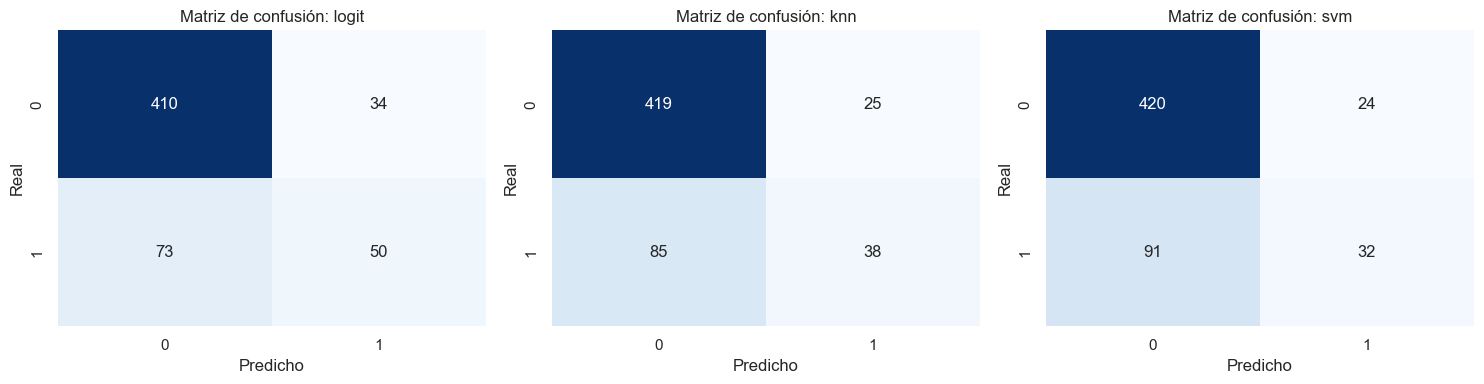

In [312]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model_name in zip(axes, ["logit", "knn", "svm"]):
    cm = base_confusions[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de confusión: {model_name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

for model_name in ["logit", "knn", "svm"]:
    cm_sum = base_confusions[model_name].sum()
    assert cm_sum == len(y_test), f"La matriz de {model_name} no suma len(y_test)."

In [ ]:
y.describe()

count    2831.000000
mean        0.227835
std         0.419509
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Target, dtype: float64

In [313]:
410 + 34 +73 + 50

567

In [315]:
param_grids = {
    "logit": {
        "model__C": [0.1, 1.0, 10.0],               
        "model__penalty": ["l2"],                   # ridge
    },
    "knn": {
        "model__n_neighbors": [5, 11, 21],          
        "model__weights": ["uniform", "distance"],  
        "model__p": [1, 2],                         
    },
    "svm": [
        {
            "model__kernel": ["linear"],
            "model__C": [0.5, 1.0, 5.0],
        },
        {
            "model__kernel": ["rbf"],
            "model__C": [0.5, 1.0, 5.0],
            "model__gamma": ["scale", 0.1, 0.01],
        },
    ],
}


In [319]:
cv_results = []
best_estimators = {}

for model_name, model_obj in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model_obj),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[model_name],
        scoring=SCORING_MAIN,
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train)

    best_pipe = grid.best_estimator_
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict.update({
        "model": model_name,
        "best_cv_f1": grid.best_score_,
        "best_params": grid.best_params_,
    })

    cv_results.append(metrics_dict)
    best_estimators[model_name] = best_pipe

cv_results_df = pd.DataFrame(cv_results).sort_values("f1", ascending=False).reset_index(drop=True)
print("Resultados tuned (ordenados por F1 en test):")
display(cv_results_df[["model", "best_cv_f1", "accuracy", "precision", "recall", "f1", "roc_auc", "best_params"]])


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Resultados tuned (ordenados por F1 en test):


,model,best_cv_f1,accuracy,precision,recall,f1,roc_auc,best_params
0,logit,0.455122,0.811287,0.595238,0.406504,0.483092,0.812679,"{'model__C': 1.0, 'model__penalty': 'l2'}"
1,knn,0.380469,0.788360,0.521739,0.292683,0.375000,0.738894,"{'model__n_neighbors': 5, 'model__p': 1, 'mode..."
2,svm,0.456208,0.798942,0.581818,0.260163,0.359551,0.804365,"{'model__C': 5.0, 'model__kernel': 'linear'}"


In [320]:
best_row = cv_results_df.iloc[0]
best_model_name = best_row["model"]
best_model = best_estimators[best_model_name]

print("Mejor modelo según F1 en test:", best_model_name)
print("Mejores hiperparámetros:")
print(best_row["best_params"])
print("Métricas test del mejor modelo:")
display(best_row[["accuracy", "precision", "recall", "f1", "roc_auc"]].to_frame("value"))

if best_row["precision"] > best_row["recall"]:
    comment = "Tradeoff observado: el modelo está más conservador (mayor precision que recall)."
elif best_row["precision"] < best_row["recall"]:
    comment = "Tradeoff observado: el modelo está más agresivo (mayor recall que precision)."
else:
    comment = "Tradeoff observado: precision y recall están balanceados."

print(comment)

Mejor modelo según F1 en test: logit
Mejores hiperparámetros:
{'model__C': 1.0, 'model__penalty': 'l2'}
Métricas test del mejor modelo:


,value
accuracy,0.811287
precision,0.595238
recall,0.406504
f1,0.483092
roc_auc,0.812679


Tradeoff observado: el modelo está más conservador (mayor precision que recall).


In [328]:
best_prob_test = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.0, 1, 0.01).tolist()
C_FP = 1350
C_FN = 3800

threshold_table = evaluate_thresholds(
    y_true=y_test,
    y_prob=best_prob_test,
    thresholds=thresholds,
    c_fp=C_FP,
    c_fn=C_FN,
)

print("Tabla de umbral vs métricas/costo:")
display(threshold_table)

best_threshold_row = threshold_table.loc[threshold_table["cost_total"].idxmin()]
print(
    f"Umbral de menor costo: {best_threshold_row['threshold']} "
    f"(Costo={best_threshold_row['cost_total']:.0f}, FP={best_threshold_row['fp']:.0f}, FN={best_threshold_row['fn']:.0f})"
)


Tabla de umbral vs métricas/costo:


,threshold,tn,fp,fn,tp,precision,recall,f1,cost_total
0,0.00,0,444,0,123,0.216931,1.00000,0.356522,599400
1,0.01,62,382,2,121,0.240557,0.98374,0.386581,523300
2,0.02,101,343,2,121,0.260776,0.98374,0.412266,470650
3,0.03,128,316,4,119,0.273563,0.96748,0.426523,441800
4,0.04,152,292,4,119,0.289538,0.96748,0.445693,409400
...,...,...,...,...,...,...,...,...,...
95,0.95,443,1,121,2,0.666667,0.01626,0.031746,461150
96,0.96,443,1,122,1,0.500000,0.00813,0.016000,464950
97,0.97,444,0,122,1,1.000000,0.00813,0.016129,463600
98,0.98,444,0,123,0,0.000000,0.00000,0.000000,467400


Umbral de menor costo: 0.24 (Costo=269250, FP=115, FN=30)


In [331]:
threshold_table.sort_values("cost_total").reset_index(drop=False)

,index,threshold,tn,fp,fn,tp,precision,recall,f1,cost_total
0,24,0.24,329,115,30,93,0.447115,0.756098,0.561934,269250
1,22,0.22,317,127,28,95,0.427928,0.772358,0.550725,277850
2,23,0.23,322,122,30,93,0.432558,0.756098,0.550296,278700
3,21,0.21,312,132,27,96,0.421053,0.780488,0.547009,280800
4,37,0.37,383,61,53,70,0.534351,0.569106,0.551181,283750
...,...,...,...,...,...,...,...,...,...,...
95,99,0.99,444,0,123,0,0.000000,0.000000,0.000000,467400
96,98,0.98,444,0,123,0,0.000000,0.000000,0.000000,467400
97,2,0.02,101,343,2,121,0.260776,0.983740,0.412266,470650
98,1,0.01,62,382,2,121,0.240557,0.983740,0.386581,523300


In [ ]:
X.head()


,idhogar,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago
0,001ff74ca,0.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,4.0,0.0,1.0,0.250000,1.0,256.00,0.000000,0.0,0.0,0.0
1,003123ec2,0.0,3.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,...,16.0,36.0,4.0,4.000000,1.0,42.25,179.666667,0.0,0.0,0.0
2,004616164,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,...,4.0,9.0,1.0,0.444444,1.0,9.00,1378.000000,0.0,0.5,0.0
3,004983866,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,4.0,0.0,1.0,1.000000,1.0,64.00,3481.000000,0.0,0.0,0.0
4,005905417,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,9.0,0.0,4.0,0.250000,4.0,81.00,196.000000,0.0,1.0,0.0


In [342]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)



In [346]:
param_grid = {
    "model__n_estimators": [100, 200,500,1000],
    "model__max_depth": [None, 1,2,3,4,5,6,7,8,9,10],
    "model__min_samples_split": [2, 5, 10,3,20],
    "model__min_samples_leaf": [1, 2,3,4,5],
}



In [347]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf)
])


In [360]:
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=60,   # solo 40 combinaciones
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=48,
    return_train_score=True
)

random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 1, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies t

In [361]:
y_prob = pipe_rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [362]:
metrics_dict = evaluate_model(y_test, y_pred, y_prob)
print(metrics_dict)

{'accuracy': 0.8165784832451499, 'precision': 0.7021276595744681, 'recall': 0.2682926829268293, 'f1': 0.38823529411764707, 'roc_auc': 0.8156449132058888}


In [363]:
print(random_search.best_params_)
print(random_search.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 9}
0.2623299146499161


In [364]:
best_model = random_search.best_estimator_

In [365]:
y_train_pred = best_model.predict(X_train)
y_train_prob = best_model.predict_proba(X_train)[:, 1]

# TEST
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print("TRAIN F1:", f1_score(y_train, y_train_pred))
print("TEST F1:", f1_score(y_test, y_test_pred))

print("TRAIN ROC AUC:", roc_auc_score(y_train, y_train_prob))
print("TEST ROC AUC:", roc_auc_score(y_test, y_test_prob))

TRAIN F1: 0.3834355828220859
TEST F1: 0.272108843537415
TRAIN ROC AUC: 0.924025979738795
TEST ROC AUC: 0.8159195781147


In [366]:
thresholds = np.arange(0, 1.0, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_t = (y_test_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.29
Best F1: 0.5754385964912281


In [367]:


confusion_matrix(y_test, y_test_pred)


array([[440,   4],
       [103,  20]])

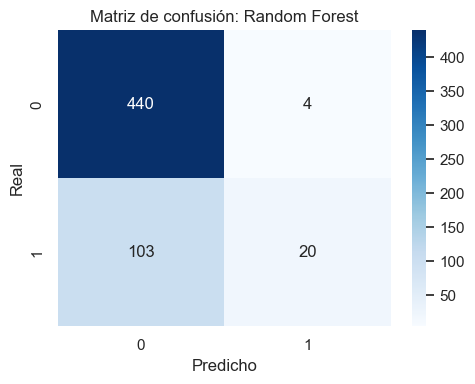

In [368]:
y_rf_pred = best_model.predict(X_test)

# Matriz
cm_rf = confusion_matrix(y_test, y_rf_pred)

# Gráfico
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, 
            annot=True, 
            fmt="d", 
            cmap="Blues")

plt.title("Matriz de confusión: Random Forest")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()